# **Voting Classifier**

Dataset: https://www.kaggle.com/datasets/nvarisha/heart-attack-data-analysis

Group 8:
- Name 1: Werren Edbert Hartawan (2802444662)
- Name 2: William Untung (2802446573)
- Major: Data Science
- Class: LC09
- Course: Model Deployment

## **Notebook**

**Setup**

In [32]:
#Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score
from sklearn.inspection import permutation_importance
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
#Load dataset
# df = pd.read_csv("Heart Attack Data Set.csv") # untuk local-run
df = pd.read_csv("https://docs.google.com/spreadsheets/d/1EE7Q8enc7CplxzNKAS3A8jlJDV3VG-7OkvEwJt6kgzI/export?format=csv&gid=354751620") # untuk collab (perlu koneksi internet)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
#Shape
print("This dataset contains (row, column):", df.shape)

#Data Overview
df.info()
df.describe()

This dataset contains (row, column): (303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
#Missing Value check
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
#Duplicates Check
duplicate_count = df.duplicated().sum()
print("Total duplicates check:", duplicate_count)

Total duplicates check: 1


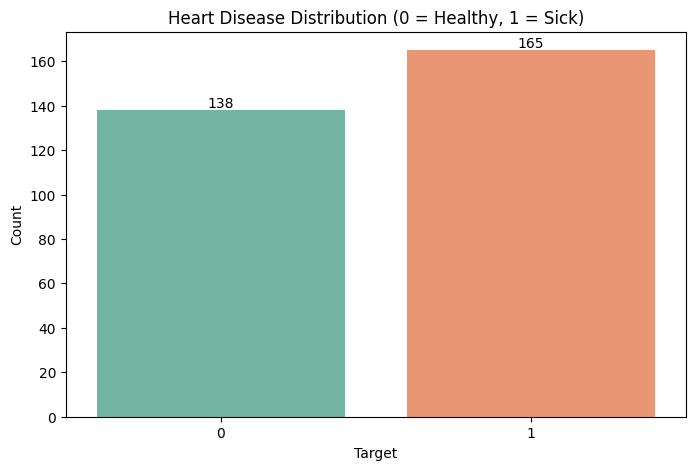

In [7]:
#Class Balance
plt.figure(figsize= (8, 5))
ax = sns.countplot(x= "target", data= df, palette= "Set2")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])

plt.title("Heart Disease Distribution (0 = Healthy, 1 = Sick)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

**Insight 1**: The target variable is well-balanced with 138 healthy instances and 165 sick instances, allowing for a reliable evaluation using standard metrics like accuracy and ROC-AUC.

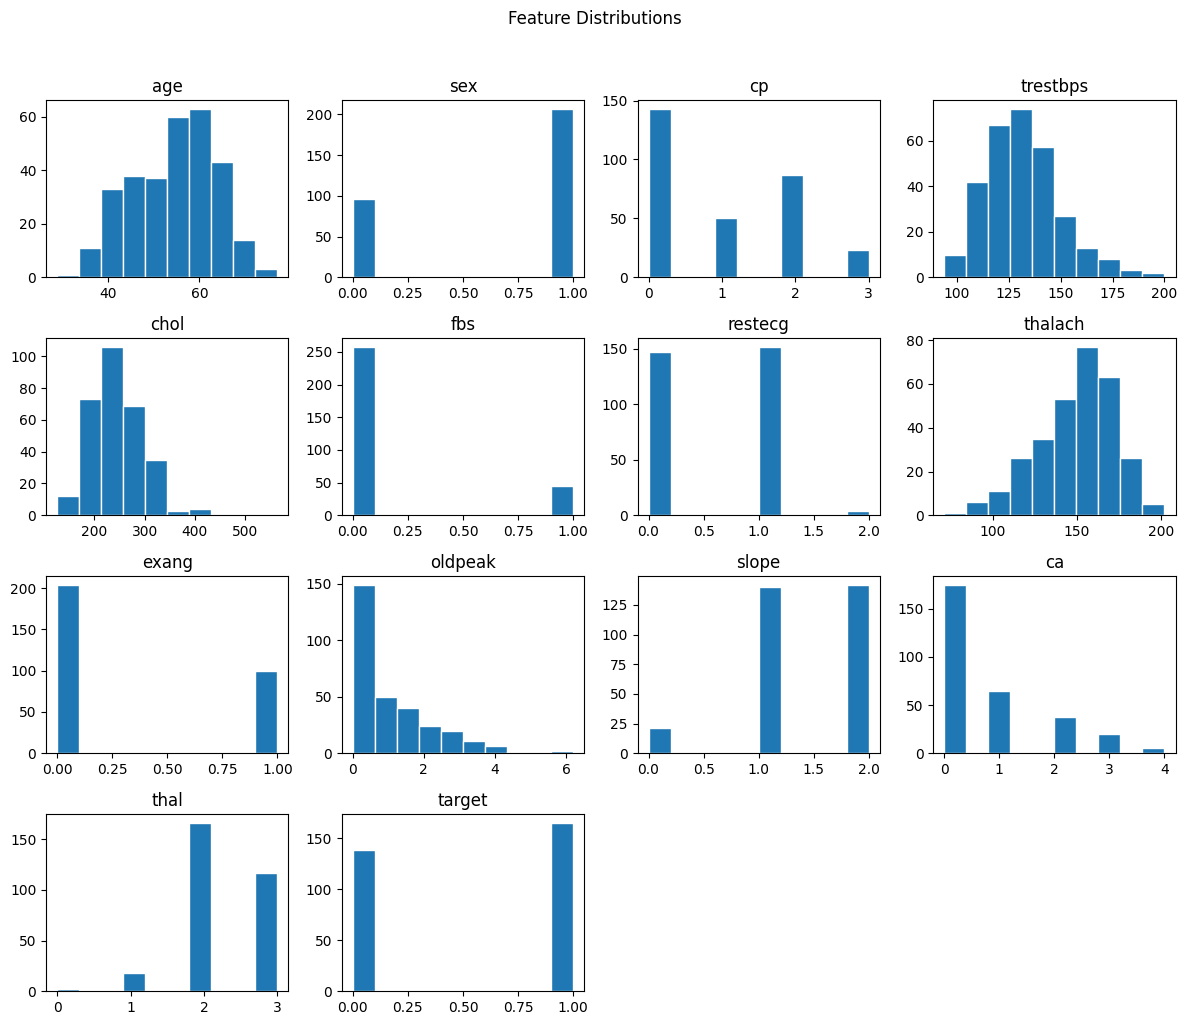

In [8]:
#Histograms
df.hist(figsize= (12, 10), grid= False, edgecolor= "white")
plt.suptitle("Feature Distributions", y= 1.02)
plt.tight_layout()
plt.show()

**Insight 2:** Numerical variables like *age*, *trestbps*, and *chol* follow a near-normal distribution, while several categorical features show expected skewness.

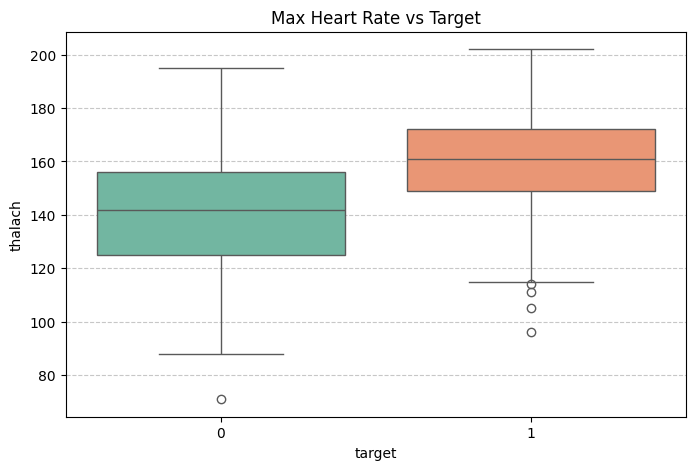

In [9]:
#Boxplot Max Heart Rate
plt.figure(figsize= (8,5))
sns.boxplot(x= "target", y= "thalach", data= df, palette= "Set2")
plt.title("Max Heart Rate vs Target")
plt.grid(axis= "y", linestyle= "--", alpha= 0.7)
plt.show()

**Insight 3:** Patients diagnosed with heart disease (Target 1) generally show a higher median maximum heart rate (*thalach*) compared to healthy patients.

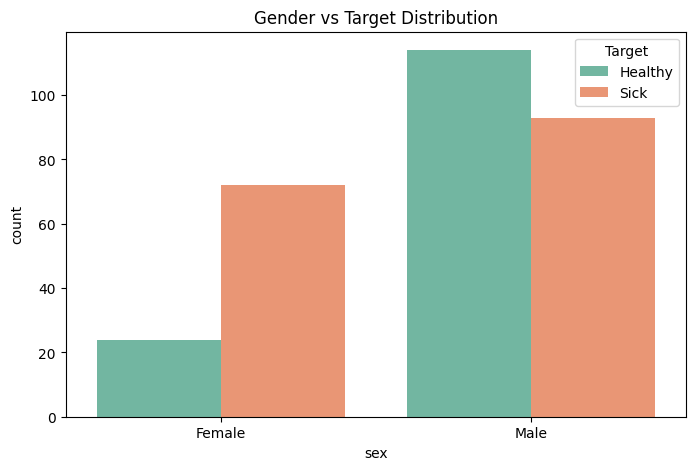

In [10]:
#Countplot Sex vs Target
plt.figure(figsize= (8, 5))
sns.countplot(x= "sex", hue= "target", data= df, palette= "Set2")
plt.title("Gender vs Target Distribution")
plt.xticks(ticks= [0, 1], labels= ["Female", "Male"])
plt.legend(title= "Target", labels= ["Healthy", "Sick"])
plt.show()

**Insight 4:** Female patients (0) have a higher proportion of heart disease cases relative to their group size, while Male patients (1) make up the majority of the total dataset.

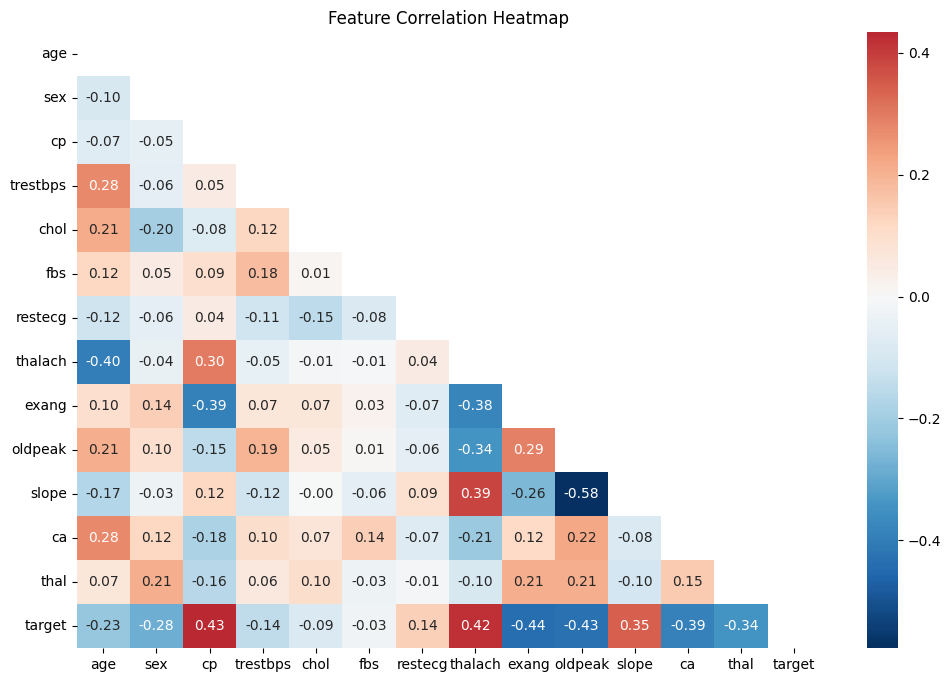

In [11]:
#Correlation Heatmap
plt.figure(figsize= (12, 8))
mask = np.triu(np.ones_like(df.corr(), dtype= bool))
sns.heatmap(df.corr(), mask= mask, annot= True, fmt= ".2f", cmap='RdBu_r', center= 0)
plt.title("Feature Correlation Heatmap")
plt.show()

**Insight 5:**
- **Top Predictors**: *cp* (chest pain) and *thalach* (max heart rate) show the strongest positive correlation with the target.
- **Strong Negative Impacts**: *exang* (exercise induced angina), *oldpeak*, and *ca* have significant negative correlations with the target.
- **Low Multicollinearity**: Independent variables show weak correlations with each other, which is ideal for modeling.

**Split Data into Train and Test set**

In [12]:
#Data split
X = df.drop(columns= ["target"])
y = df["target"]

#Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42, stratify= y)
print(f"Total Rows (before): {len(df)}")
print(f"Total Rows for Training Set: {len(X_train)}")
print(f"Total Rows for Testing Set: {len(X_test)}")

Total Rows (before): 303
Total Rows for Training Set: 242
Total Rows for Testing Set: 61


In [13]:
#Check Outliers
def check_outliers(df_train):
    check_outliers = ["age", "trestbps", "chol", "thalach", "oldpeak"]
    for col in check_outliers:
        Q1 = df_train[col].quantile(0.25)
        Q3 = df_train[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df_train[(df_train[col] < lower_bound) | (df_train[col] > upper_bound)]
        print(f"Feature {col}: Found {len(outliers)} outliers")

check_outliers(X_train)

Feature age: Found 0 outliers
Feature trestbps: Found 9 outliers
Feature chol: Found 3 outliers
Feature thalach: Found 1 outliers
Feature oldpeak: Found 2 outliers


In [15]:
train = pd.concat([X_train, y_train], axis= 1)
train = train.drop_duplicates(keep= 'first')

X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

print(f"Total duplicates now in train set: {train.duplicated().sum()}")

Total duplicates now in train set: 0


In [17]:
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
bool_cols = ['sex', 'fbs', 'exang']
ordinal_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', StandardScaler(), ordinal_cols),
        ('bool', 'passthrough', bool_cols)
    ]
)

In [18]:
#Define Logistic Regressions Pipelines
log_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('lr', LogisticRegression(random_state= 42))
])

#Define Random Forest Pipelines
rf_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(random_state= 42))
])

#Define XGBoost Pipelines
xgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('xgb', XGBClassifier(random_state= 42, eval_metric= 'logloss'))
])

dt_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('dt', DecisionTreeClassifier(random_state= 42))
])

hgb_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('hgb', HistGradientBoostingClassifier(random_state= 42))
])

In [19]:
#Define ParamsGrid
log_param = {
    'lr__max_iter': [100, 500, 1000],
    'lr__C': [0.1, 0.5, 1.5],
    'lr__class_weight': [None, 'balanced', {0 : 2, 1 : 1}]
}

rf_param = {
    'rf__n_estimators': [100, 200, 400, 600],
    'rf__max_depth': [4, 7, 8, 10],
    'rf__min_samples_split': [4, 6, 8]
}

xgb_param = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__max_depth': [5, 8, 10, 11],
    'xgb__learning_rate': [0.001, 0.005, 0.01, 1.0]
}

dt_param = {
    'dt__criterion': ['gini'],
    'dt__max_depth': [4, 5, 8, 9],
    'dt__min_samples_split': [5, 15, 25],
    'dt__min_samples_leaf' : [10, 20, 40, 60]
}

hgb_param = {
    'hgb__learning_rate': [0.005, 0.03],
    'hgb__max_depth': [None, 3, 4],
    'hgb__max_iter': [100],
    'hgb__min_samples_leaf': [10, 15, 20, 25]
}

In [20]:
#GridSearchCV
log_grid = GridSearchCV(
    log_pipe,
    log_param,
    cv= 5,
    scoring= "recall",
    n_jobs=-1
)

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param,
    cv= 5,
    scoring= "recall",
    n_jobs= -1
)

xgb_grid = GridSearchCV(
    xgb_pipe,
    xgb_param,
    cv= 5,
    scoring= "recall",
    n_jobs= -1
)

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param,
    cv= 5,
    scoring= "recall",
    n_jobs= -1
)

hgb_grid = GridSearchCV(
    hgb_pipe,
    hgb_param,
    cv= 5,
    scoring= "recall",
    n_jobs= -1
)

In [21]:
#Fit Logistic Regression Model
log_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('ord',
                                                                         StandardScaler(),
                                                                         ['cp',
                                                                          'restecg',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['sex',
                                                                          'fbs',
                                                                          'exang'])])),
                                       ('lr',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 0.5, 1.5],
                         'lr__class_weight': [None, 'balanced', {0: 2, 1: 1}],
                         'lr__max_iter': [100, 500, 1000]},
             scoring='recall')

In [22]:
#Fit Random Forest Model
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('ord',
                                                                         StandardScaler(),
                                                                         ['cp',
                                                                          'restecg',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['sex',
                                                                          'fbs',
                                                                          'exang'])])),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [4, 7, 8, 10],
                         'rf__min_samples_split': [4, 6, 8],
                         'rf__n_estimators': [100, 200, 400, 600]},
             scoring='recall')

In [23]:
#Fit XGBoost Model
xgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('ord',
                                                                         StandardScaler(),
                                                                         ['cp',
                                                                          'restecg',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['sex',
                                                                          'fbs',
                                                                          'exang'])])),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_byle...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__learning_rate': [0.001, 0.005, 0.01, 1.0],
                         'xgb__max_depth': [5, 8, 10, 11],
                         'xgb__n_estimators': [100, 300, 500]},
             scoring='recall')

In [24]:
dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('ord',
                                                                         StandardScaler(),
                                                                         ['cp',
                                                                          'restecg',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['sex',
                                                                          'fbs',
                                                                          'exang'])])),
                                       ('dt',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'dt__criterion': ['gini'],
                         'dt__max_depth': [4, 5, 8, 9],
                         'dt__min_samples_leaf': [10, 20, 40, 60],
                         'dt__min_samples_split': [5, 15, 25]},
             scoring='recall')

In [25]:
hgb_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'trestbps',
                                                                          'chol',
                                                                          'thalach',
                                                                          'oldpeak']),
                                                                        ('ord',
                                                                         StandardScaler(),
                                                                         ['cp',
                                                                          'restecg',
                                                                          'slope',
                                                                          'ca',
                                                                          'thal']),
                                                                        ('bool',
                                                                         'passthrough',
                                                                         ['sex',
                                                                          'fbs',
                                                                          'exang'])])),
                                       ('hgb',
                                        HistGradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'hgb__learning_rate': [0.005, 0.03],
                         'hgb__max_depth': [None, 3, 4], 'hgb__max_iter': [100],
                         'hgb__min_samples_leaf': [10, 15, 20, 25]},
             scoring='recall')

In [26]:
#Tuning Results by Models (Best Parameters and Score)
tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost", "Decision Tree", "HistGradientBoosting"],
    "Best CV Recall Score": [log_grid.best_score_, rf_grid.best_score_, xgb_grid.best_score_, dt_grid.best_score_, hgb_grid.best_score_],
    "Best Parameters": [str(log_grid.best_params_), str(rf_grid.best_params_), str(xgb_grid.best_params_), str(dt_grid.best_params_), str(hgb_grid.best_params_)]
})
pd.set_option('display.max_colwidth', None)

tuning_results

,Model,Best CV Recall Score,Best Parameters
0,Logistic Regression,0.915954,"{'lr__C': 0.1, 'lr__class_weight': None, 'lr__max_iter': 100}"
1,Random Forest,0.915954,"{'rf__max_depth': 4, 'rf__min_samples_split': 6, 'rf__n_estimators': 100}"
2,XGBoost,0.984900,"{'xgb__learning_rate': 0.001, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}"
3,Decision Tree,0.827920,"{'dt__criterion': 'gini', 'dt__max_depth': 4, 'dt__min_samples_leaf': 20, 'dt__min_samples_split': 5}"
4,HistGradientBoosting,0.924217,"{'hgb__learning_rate': 0.005, 'hgb__max_depth': 3, 'hgb__max_iter': 100, 'hgb__min_samples_leaf': 15}"


In [50]:
#Extract Best Estimators
best_rf = rf_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
best_hgb = hgb_grid.best_estimator_

#Voting Classifier
voting_clf = VotingClassifier(
    estimators= [
        ('rf', best_rf),
        ('xgb', best_xgb),
        ('hgb', best_hgb)
    ],
    voting= 'soft',
    weights= [2, 1, 3]
)

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('preprocess',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['age',
                                                                                 'trestbps',
                                                                                 'chol',
                                                                                 'thalach',
                                                                                 'oldpeak']),
                                                                               ('ord',
                                                                                StandardScaler(),
                                                                                ['cp',
                                                                                 'restecg',
                                                                                 'slope',
                                                                                 'ca',
                                                                                 'thal']),
                                                                               ('bool',
                                                                                'passthrough',
                                                                                ['sex',
                                                                                 'fbs',
                                                                                 'exang'])])),
                                              ('rf',
                                               RandomForestClassifier(max_depth=4,
                                                                      min_samples_split=6,
                                                                      random_stat...
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                ['age',
                                                                                 'trestbps',
                                                                                 'chol',
                                                                                 'thalach',
                                                                                 'oldpeak']),
                                                                               ('ord',
                                                                                StandardScaler(),
                                                                                ['cp',
                                                                                 'restecg',
                                                                                 'slope',
                                                                                 'ca',
                                                                                 'thal']),
                                                                               ('bool',
                                                                                'passthrough',
                                                                                ['sex',
                                                                                 'fbs',
                                                                                 'exang'])])),
                                              ('hgb',
                                               HistGradientBoostingClassifier(learn

Perbedaan voting soft dan hard:
- soft : membandingkan probabilitas prediksi tiap model
- hard : membandingkan class prediksi tiap model (0 / 1)

model di buat dengan voting soft untuk pendekatan lebih beralasan (reasoning) karena ini dataset untuk prediksi medis dan memiliki impact nyata pada hasilnya maka perlu alasan dalam bentuk probabilitas confidence model.

hard juga dapat dibuatkan probabilitas nya melalui rata-rata probabilitas tiap model yang dibandingkan tetapi hasil tidak memiliki alasan lebih detail.

Contoh (class target dibagi menjadi -> (P(0) | P(1))):
- Random Forest dengan prediksi probabilitas (0.70 | 0.30) = 0
- XGBoost dengan prediksi probabilitas (0.20 | 0.80) = 1
- HistGradientBoosting dengan prediksi probabilitas (0.55 | 0.45) = 0

Hard = [0, 1, 0] -> 0<br>
Soft:<br>
P(0) = (0.70 + 0.20 + 0.55) / 3 = 0.48<br>
P(1) = (0.30 + 0.80 + 0.45) / 3 = 0.52<br>
Hasil Soft -> 1

In [51]:
# Hasil Contoh
print(f'Hard = [0, 1, 0] -> 0')
print(f'Soft:\nP(0) = {(0.70 + 0.20 + 0.55) / 3:.2f}\nP(1) = {(0.30 + 0.80 + 0.45) / 3:.2f}')
print(f"Hasil Soft -> 1")

Hard = [0, 1, 0] -> 0
Soft:
P(0) = 0.48
P(1) = 0.52
Hasil Soft -> 1


*Kesimpulan*:
- **Hard** mendukung class mayoritas
- **Soft** mendukung class paling diyakini

In [52]:
#Get Predictions
pred_rf = best_rf.predict(X_test)
pred_xgb = best_xgb.predict(X_test)
pred_hgb = best_hgb.predict(X_test)
pred_voting = voting_clf.predict(X_test)

In [53]:
#Get Probabilities (Probability of class 1)
proba_rf = best_rf.predict_proba(X_test)[:, 1]
proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
proba_hgb = best_hgb.predict_proba(X_test)[:, 1]
proba_voting = voting_clf.predict_proba(X_test)[:, 1] # soft
# proba_voting = (proba_log + proba_rf + proba_hgb) / 3 # hard

In [54]:
print("ROC-AUC Scores")
print(f"Random Forest         : {roc_auc_score(y_test, proba_rf):.4f}")
print(f"XGBoost               : {roc_auc_score(y_test, proba_xgb):.4f}")
print(f"HistGradientBoosting  : {roc_auc_score(y_test, proba_hgb):.4f}")

#DataFrame to Compare Actual vs Predictions vs Probabilities
compare_df = pd.DataFrame({
    'Actual': y_test.values,
    'RF_Pred': pred_rf, 'RF_Prob': np.round(proba_rf, 3),
    'XGB_Pred': pred_xgb, 'XGB_Prob': np.round(proba_xgb, 3),
    'HGB_Pred': pred_xgb, 'HGB_Prob': np.round(proba_hgb, 3),
    'Voting_Pred': pred_voting, 'Voting_Prob': np.round(proba_voting, 3)
})

display(compare_df.head(10))
print("Recall (Positive Class)")
print(f"Random Forest         : {recall_score(y_test, pred_rf, pos_label=1):.4f}")
print(f"XGBoost               : {recall_score(y_test, pred_xgb, pos_label=1):.4f}")
print(f"HistGradientBoosting  : {recall_score(y_test, pred_hgb, pos_label=1):.4f}")

print("Recall (Negative Class)")
print(f"Random Forest         : {recall_score(y_test, pred_rf, pos_label=0):.4f}")
print(f"XGBoost               : {recall_score(y_test, pred_xgb, pos_label=0):.4f}")
print(f"HistGradientBoosting  : {recall_score(y_test, pred_hgb, pos_label=0):.4f}")

ROC-AUC Scores
Random Forest         : 0.9134
XGBoost               : 0.7938
HistGradientBoosting  : 0.8512


,Actual,RF_Pred,RF_Prob,XGB_Pred,XGB_Prob,HGB_Pred,HGB_Prob,Voting_Pred,Voting_Prob
0,0,0,0.225,1,0.541,1,0.402,0,0.366
1,0,0,0.380,1,0.513,1,0.429,0,0.426
2,0,0,0.082,0,0.495,0,0.330,0,0.275
3,0,1,0.698,1,0.580,1,0.638,1,0.648
4,0,1,0.601,1,0.545,1,0.608,1,0.595
5,0,0,0.274,1,0.514,1,0.472,0,0.413
6,1,1,0.871,1,0.580,1,0.603,1,0.689
7,0,0,0.342,1,0.509,1,0.426,0,0.412
8,1,1,0.820,1,0.580,1,0.635,1,0.688
9,0,1,0.555,1,0.545,1,0.608,1,0.580


Recall (Positive Class)
Random Forest         : 0.9394
XGBoost               : 1.0000
HistGradientBoosting  : 0.8485
Recall (Negative Class)
Random Forest         : 0.6429
XGBoost               : 0.2500
HistGradientBoosting  : 0.6786


AUC menunjukan seberapa andal model membedakan class 0 dan class 1
karena itu dari hasil score auc tiap model dari roc_auc_score dapat diurutkan sebagai berikut: Random Forest Classifier (0.92) > HistGradientBoosting Classifier (0.85) > XGBoost Classifier (0.79)

Recall Class Positive menunjukkan sensitifitas model dalam memprediksi class positif (1). Recall (+) dapat diurutkan sebagai berikut: XGBoost Classifier (1.00) > Random Forest Classifier (0.94) > HistGradientBoosting Classifier (0.85)

Recall Class Negative menunjukkan sensitifitas model dalam memprediksi class negatif (0). Recall (-) dapat diurutkan sebagai berikut: HistGradientBoosting Classifier (0.68) > Random Forest Classifier (0.64) > XGBoosting Classifier (0.25)

Ditentukan pembobotan (weighting model voting) sebagai berikut: (rf, xgb, hgb) -> (2, 1, 3)

- XGBoosting memang andal dalam mendeteksi class 1, akan tetapi diikuti dengan pengorbanan dalam keandalan mendeteksi class 0
- RandomForest andal dalam membedakan class 1 dan 0, model juga cukup stabil dalam mendeteksi class 1 dan 0 dengan probabilitas di level menengah dari urutan recall positif dan negatif diatas
- HistGradientBoosting cukup andal membedakan class 1 dan 0, tetapi model cenderung main aman dalam memilih class 1 dan banyak mengorbankan class 1 untuk mendeteksi class 0 (mengincar keseimbangan antara class 1 dan 0)

sebenarnya model rf sudah sangat stabil dan cukup untuk mendeteksi class 1 dan 0 (sedikit false negatif)

dengan voting classifier kelemahan rf dapat ditutupi dengan XGB yang fokus ke class 1 (mayoritas) dan HGB yang fokus mencari keseimbangan dengan mendukung class 0 (minoritas)

In [48]:
print("Recall (Positive Class)")
print(f"Voting Classifier     : {recall_score(y_test, pred_voting, pos_label=1):.4f}")
print("ROC-AUC Scores")
print(f"Voting Classifier     : {roc_auc_score(y_test, proba_voting):.4f}")

Recall (Positive Class)
Voting Classifier     : 0.9697
ROC-AUC Scores
Voting Classifier     : 0.8961


**Classification Report**

In [49]:
#Classification Report Voting Classifier
print("Classification Report")
print(classification_report(y_test, pred_voting))
confusion_matrix(y_test, pred_voting)

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.61      0.74        28
           1       0.74      0.97      0.84        33

    accuracy                           0.80        61
   macro avg       0.84      0.79      0.79        61
weighted avg       0.84      0.80      0.79        61



array([[17, 11],
       [ 1, 32]])

**Confusion Matrix Berdasarkan weighting model voting (rf, xgb, hgb):**<br>
- weights= (2, 1, 2):<br>
[18, 10]<br>
[ 1, 32]<br><br>
- weights= (2, 1, 3):<br>
[18, 10]<br>
[ 0, 33]]<br><br>
- weights= (1, 2, 1):<br>
[16, 12]<br>
[ 0, 33]<br>

**Features Importance**

In [36]:
rf_importance = voting_clf.named_estimators_['rf'].named_steps['rf'].feature_importances_
xgb_importance = voting_clf.named_estimators_['xgb'].named_steps['xgb'].feature_importances_
# HistGradientBoosting beda ada dibawah

In [37]:
# Ini buat Hist pake permutation importance
hgb_importance = permutation_importance(
    voting_clf.named_estimators_['hgb'],
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='recall'  # bisa juga 'roc_auc'
).importances_mean

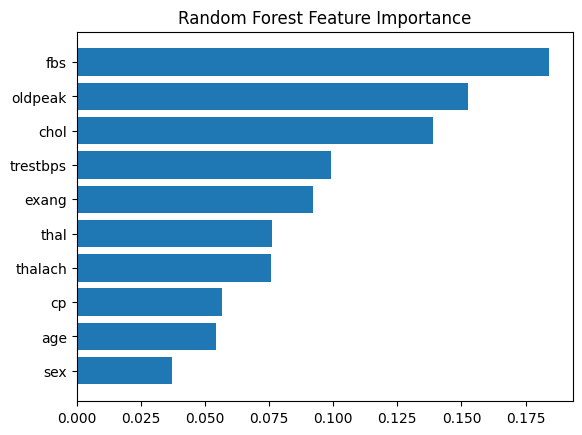

In [38]:
rf_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_importance
}).sort_values(by='importance', ascending=False).head(10)

# rf_df['importance'] = rf_df['importance'].head(10) * 100

plt.figure()
plt.barh(rf_df['feature'], rf_df['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.show()

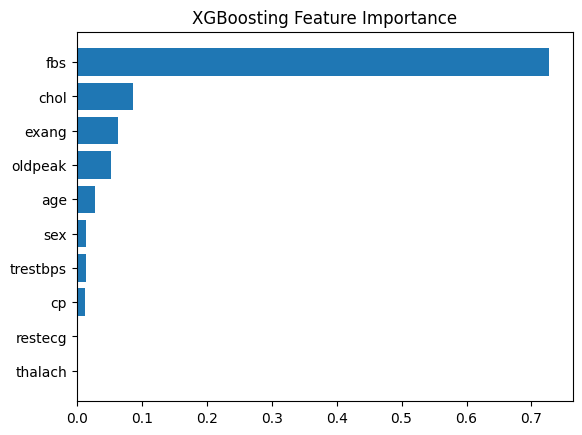

In [39]:
xgb_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_importance
}).sort_values(by='importance', ascending=False).head(10)

# xgb_df['importance'] = xgb_df['importance'].head(10) * 100

plt.figure()
plt.barh(xgb_df['feature'], xgb_df['importance'])
plt.gca().invert_yaxis()
plt.title("XGBoosting Feature Importance")
plt.show()

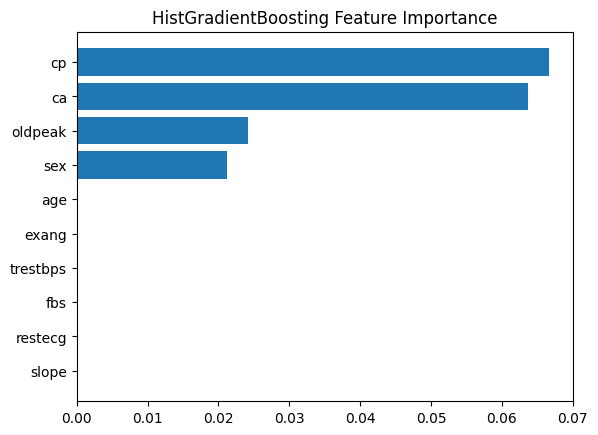

In [40]:
hgb_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': hgb_importance
}).sort_values(by='importance', ascending=False).head(10)

# hgb_df['importance'] = hgb_df['importance'] * 100

# Plot
plt.figure()
plt.barh(hgb_df['feature'], hgb_df['importance'])
plt.gca().invert_yaxis()
plt.title("HistGradientBoosting Feature Importance")
plt.show()

In [41]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'rf': rf_importance,
    'xgb': xgb_importance,
    'hgb' : hgb_importance
})

importance_df['mean_importance'] = importance_df[['rf','xgb','hgb']].mean(axis=1)

importance_df[['rf','xgb', 'hgb','mean_importance']] = (
    importance_df[['rf','xgb', 'hgb','mean_importance']] * 100
)

importance_df = importance_df.sort_values(by='mean_importance', ascending=False)

importance_df.reset_index(drop=True)

,feature,rf,xgb,hgb,mean_importance
0,fbs,18.417359,72.711929,0.000000,30.376428
1,oldpeak,15.263466,5.317889,2.424242,7.668533
2,chol,13.878297,8.677520,-0.606061,7.316585
3,exang,9.218188,6.410634,0.000000,5.209607
4,cp,5.648249,1.225856,6.666667,4.513591
5,trestbps,9.920314,1.353910,0.000000,3.758075
6,age,5.443534,2.821319,0.000000,2.754951
7,thalach,7.585746,0.000000,0.000000,2.528582
8,sex,3.720375,1.480933,2.121212,2.440840
9,thal,7.610137,0.000000,-0.303030,2.435702


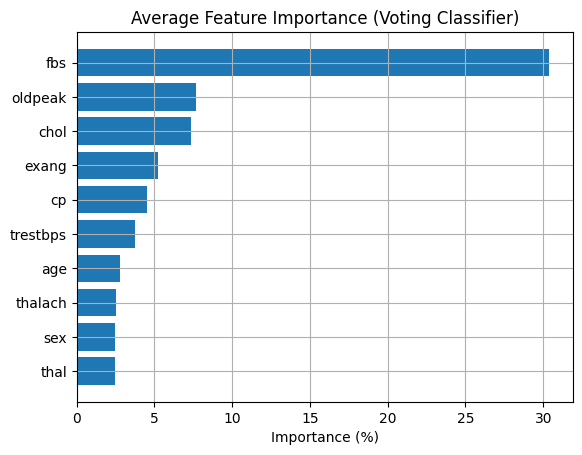

In [42]:
top_n = 10
plot_df = importance_df.head(top_n).copy()

# ubah ke persen
# plot_df['mean_importance'] = plot_df['mean_importance'] * 100

plt.figure()
plt.barh(plot_df['feature'], plot_df['mean_importance'])
plt.gca().invert_yaxis()
plt.title("Average Feature Importance (Voting Classifier)")
plt.xlabel("Importance (%)")
plt.grid(True)
plt.show()